### import libraries

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

### Load cleaned Dataset

In [13]:
import pandas as pd
df = pd.read_csv(
    "../Dataset/Cleaned_Retail_Sales_Dataset.csv"
)
df.head()

,Transaction_ID,Customer_ID,Product_Category,Product_Name,Quantity,Unit_Price,Total_Amount,Purchase_Date,Customer_City,Payment_Method,Customer_Age,Customer_Gender
0,T0001,C0126,Sports,Football,1,25000,25000,2025-05-21,Karachi,Credit Card,65.0,Male
1,T0002,C0048,Sports,Football,7,500,3500,2025-01-16,Karachi,Credit Card,50.0,Male
2,T0003,C0302,Beauty,Skin Care,7,1000,7000,2025-08-18,Lahore,Cash,28.0,Female
3,T0004,C0053,Grocery,Snacks,3,1000,3000,2025-06-22,Lahore,Online Payment,24.0,Female
4,T0005,C0275,Grocery,Snacks,1,25000,25000,2025-08-24,Islamabad,Online Payment,23.0,Female


### check Main KPIS

In [14]:
# Total Revenues
total_revenue = df["Total_Amount"].sum()
print("Total Revenue:",total_revenue)

Total Revenue: 73085000


In [15]:
# Total Orders
total_orders = df["Transaction_ID"].nunique()
print("Total Orders:",total_orders)

Total Orders: 1188


In [16]:
# Average Order Value
average_order_value = (total_revenue /total_orders)
print("Average Order Value:",average_order_value)

Average Order Value: 61519.360269360266


### check which product generates a highest sale

In [17]:
top_products = (df.groupby("Product_Name")["Total_Amount"].sum().sort_values(ascending=False))
top_products.head(10)

Product_Name
Yoga Mat       4576000
Table          3991000
Snacks         3968500
Smart Watch    3856000
Headphones     3779500
Shirt          3673500
Football       3462000
Laptop         3323500
Coffee         3185000
Rice           3183000
Name: Total_Amount, dtype: int64

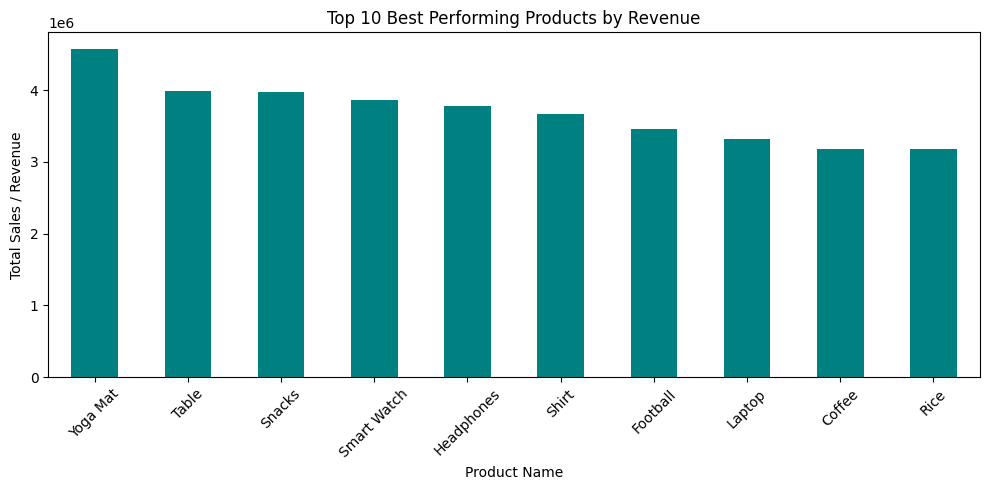

In [19]:
plt.figure(figsize=(10, 5))
top_products.head(10).plot(kind="bar", color="teal")
plt.title("Top 10 Best Performing Products by Revenue")
plt.xlabel("Product Name")
plt.ylabel("Total Sales / Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### check which category has lowest value

In [20]:
category_performance = df.groupby("Product_Category")["Total_Amount"].sum().sort_values()
category_performance.head(3)

Product_Category
Beauty       10363000
Furniture    11275000
Clothing     11996000
Name: Total_Amount, dtype: int64

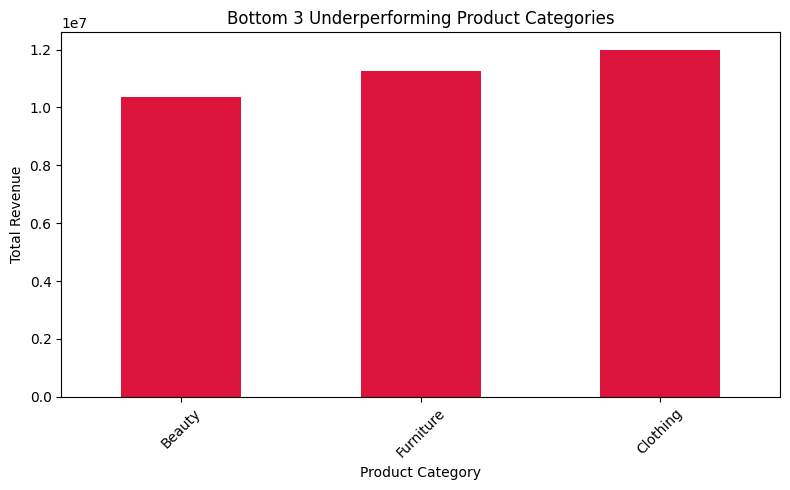

In [21]:
plt.figure(figsize=(8, 5))
category_performance.head(3).plot(kind="bar", color="crimson")
plt.title("Bottom 3 Underperforming Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### check  seasonal trends

In [23]:
#  First ensure Purchase_Date is converted to datetime format
df["Purchase_Date"] = pd.to_datetime(df["Purchase_Date"])
#  Extract the Month Name from the Purchase_Date column
df["Month"] = df["Purchase_Date"].dt.month_name()
# Now group by Month and sum the Total_Amount safely
season_sales = df.groupby("Month")["Total_Amount"].sum()
print("Monthly Sales Summary:\n", season_sales)
peak_month = season_sales.idxmax()
print(f"\n Peak Month for Sales: {peak_month}")

Monthly Sales Summary:
 Month
April        5444000
August       5304000
December     6715500
February     6298000
January      6818500
July         4796000
June         7140500
March        8385000
May          4398000
November     5074000
October      7658000
September    5053500
Name: Total_Amount, dtype: int64

 Peak Month for Sales: March


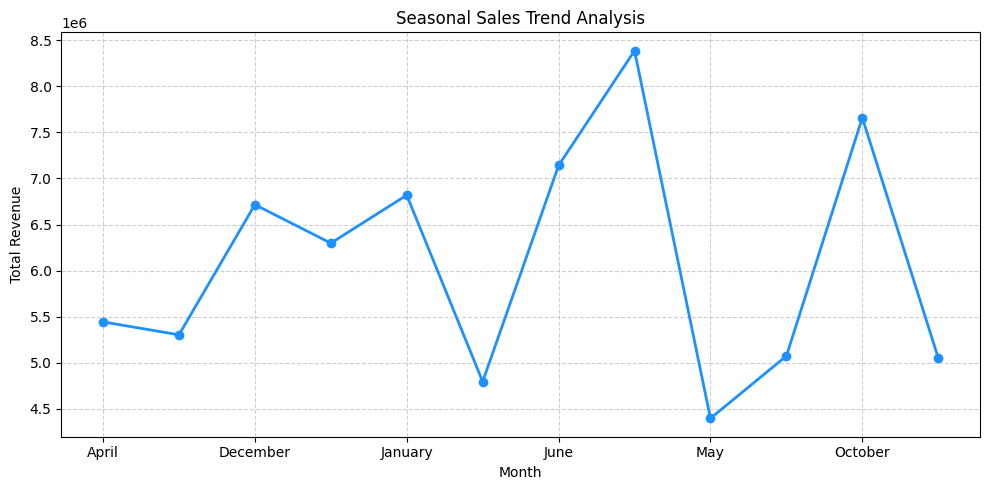

In [24]:
plt.figure(figsize=(10, 5))
season_sales.plot(kind="line", marker="o", color="dodgerblue", linewidth=2)
plt.title("Seasonal Sales Trend Analysis")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### analyse customer behaviour

In [25]:
# Group by Customer_ID and sum the Total_Amount to find high-value customers
customer_value = df.groupby("Customer_ID")["Total_Amount"].sum().sort_values(ascending=False)
# Display the top 10 high-value customers
print("Top 10 High-Value Customers:")
customer_value.head(10)

Top 10 High-Value Customers:


Customer_ID
C0493    878000
C0338    876000
C0421    760000
C0383    748000
C0151    740000
C0009    681000
C0154    661000
C0196    650000
C0325    635000
C0134    626000
Name: Total_Amount, dtype: int64

In [27]:
# Customer Location Analysis (Top cities by revenue)
city_performance = df.groupby("Customer_City")["Total_Amount"].sum().sort_values(ascending=False)
print("\nRevenue by Customer Location (City):")
print(city_performance.head())



Revenue by Customer Location (City):
Customer_City
Karachi       14113000
Multan        12160000
Lahore        12135500
Faisalabad    12063000
Islamabad     10976500
Name: Total_Amount, dtype: int64


In [28]:
# Payment Preferences Analysis (Most preferred payment methods)
payment_prefs = df["Payment_Method"].value_counts()
print("\nCustomer Payment Preferences:")
print(payment_prefs)


Customer Payment Preferences:
Payment_Method
Credit Card       209
Jazzcash          208
Easypaisa         199
Online Payment    186
Cash              184
Debit Card        179
Unknown            20
Card                1
Easy Paisa          1
Jazz Cash           1
Name: count, dtype: int64


### analyse payment behaviour

In [29]:
# Group by Payment_Method and calculate total revenue for each method
payment_sales = df.groupby("Payment_Method")["Total_Amount"].sum().sort_values(ascending=False)
payment_sales

Payment_Method
Easypaisa         12663000
Debit Card        12147000
Cash              12025000
Jazzcash          11942000
Online Payment    11655500
Credit Card       10907000
Unknown            1721500
Jazz Cash            15000
Easy Paisa            8000
Card                  1000
Name: Total_Amount, dtype: int64

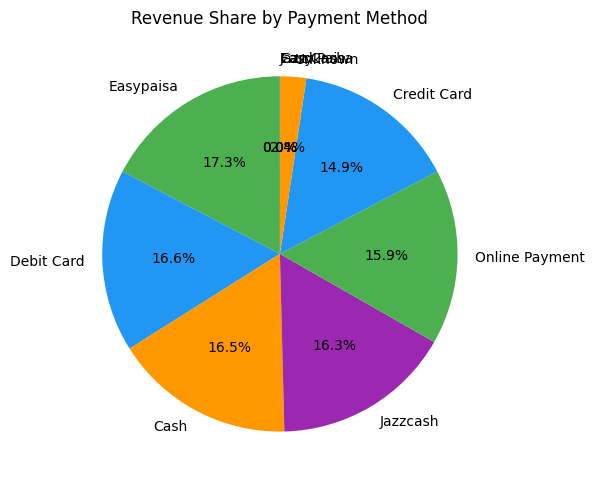

In [30]:
plt.figure(figsize=(6, 6))
payment_sales.plot(kind="pie", autopct="%1.1f%%", startangle=90, colors=["#4CAF50", "#2196F3", "#FF9800", "#9C27B0"])
plt.title("Revenue Share by Payment Method")
plt.ylabel("")  
plt.tight_layout()
plt.show()

#  Revenue Opportunity Identification (Strategic Recommendations)

Based on the data-driven insights gathered across the previous analytical steps, here are the core strategic pillars to maximize future revenue opportunities:


###  Opportunity 1: Scaling up High-Value Verticals (Electronics/Top Products)
* **Data Reason:** These segments contribute the highest absolute financial revenue to the business, making them our primary growth engines.
* **Strategic Action:** 
  * Proactively increase safety stock and inventory depths for top-performing items to avoid stockouts.
  * Introduce **"Smart Bundling"** offers (e.g., pairing high-margin accessories with top-selling core products) to artificially push the Average Order Value (AOV) higher.


###  Opportunity 2: Re-engineering Weak Categories
* **Data Reason:** Certain product categories have been identified as low-revenue generators, creating an efficiency drag on warehouse overheads.
* **Strategic Action:** 
  * Run highly targeted, time-bound promotional discount campaigns to clear slow-moving inventory.
  * Conduct immediate customer preference surveys or review pricing structures to understand if the underperformance is due to bad pricing or lack of product demand.


###  Opportunity 3: Precision Customer Retention 
* **Data Reason:** The customer spending analysis isolated a small group of high-value consumers who contribute disproportionately to the total revenue.
* **Strategic Action:** 
  * Design and launch an exclusive **Tiered Loyalty Program** for top spenders.
  * Implement personalized email/SMS marketing workflows with early-access product launches and VIP rewards to increase customer lifetime value (LTV).



###  Opportunity 4: Proactive Seasonal & Operational Planning
* **Data Reason:** Quantitative seasonal analysis explicitly proved that purchasing activity is tied heavily to specific peak months.
* **Strategic Action:** 
  * Align supply chain procurement cycles to ensure maximum inventory readiness exactly **30 to 45 days prior** to identified peak months.
  * Shift the core marketing and ad spend budgets toward these seasonal spikes to capture maximum consumer wallet share when buying intent is naturally at its highest.